In [122]:
from Bio import SeqIO
from Bio.Seq import Seq

In [123]:
seqA = SeqIO.read('./a.fasta', 'fasta').seq
print(seqA)

ATGGTGTTGGATCTGGACTTGTTTCGGACGGATAAAGGAGGAGACCCGGACCGCATCCGAGAGACGCAAAAGAACCGCTTCAAGGACCCGGGACTCGTGGATCGGCTGGTGAAGGCGGACGGCGAGTGGCGAAAATGCAGATTTCAGACCGACAACTTGAACAAGCTGAAGAACCTATGCAGCAAGACAATTGGAGAGAAAATGAAGAAAAAAGAGCCAGTGGGAAATGATGAGTCCATTCCGGAGAACTTGTTAAATCTCGATGACCTCACTTCAGACACTTTAGCTAACCTGAAAGTGTCACAGATCAAAAAACTCCGACTCCTCATCGACGAAGCCATCCTGAAGTGTGACGCCCAGCGGATAAAGCTGCAGGAATAGCGGTTTGAGAACCTCCGCGAGCGATTCGATGGCTAGGTCCTGCATCCCTCGGTGCCCATCAGTAACGATGAGGATGCGGACAACAAAGTCGAGAGGATCTGGGGTGACTGCACCGTCAAGAAGAAGTACTCGCACGTGGACCTGGTGGTGATGGTCGATGGCTTTGAAGGCGAAAAAGGGGTCGTGGTGGCTGGCAGTCGAGGGTACTTCCTGAAGGGGCCCCTGGTGTTCCTGGAACAGGCGCTCATCCAGTACGCCCTTCGCACCTTGGGAAGTCGGGGCTACATTCCCATTTACACCCCGTTTTTCATGAGGAAGGAGGTCATGCAGGAGGTGGCACAGCTCAGCCAGTTTGATGAAGAGCTTTACAAGGTGATTGGCAAAGGCAGTGAAAAGTCTGACGACAACTCCTACGATGAGAAATACCTGATTGCCACCTCCGAGCAGCCCATCGCTGCTCTCCACCGAGATGAGTGGCTACGGCCAGAGGATTTGCCCATCAAGTATGCTGGCCTGTCCACCTGCTTTCGCCAGGAGGTGGGCTCCCACGGCCGGGACACCCGCGGCATCTTCCGAGTCCATCAGTTTGAGAAGATCGAGCAGTTTGTCTACGCGTCAC

In [124]:
seqB = SeqIO.read('./b.fasta', 'fasta').seq
print(seqB)

GTGTCAGTGGAACTTTGGCAGCAGTGCGTGGAGCTTTTGCGCGATGAGCTGCCTGCCCAGCAATTCAACACCTGGATCCGTCCACTACAGGTCGAAGCCGAAGGCGACGAGTTGCGTGTTTACGCGCCCAATCGTTTTGTTCTCGACTGGGTCAACGAGAAGTACCTGAGCCGCGTGCTCGAATTGCTCGATGAACACGGCAACGGCCTCGCACCCGTGCTCTCCTTATTAATAGGCAGCAAACGTAGCTCCGCACCTCGTGCTGCGCCGAACGCGCCATTGGCCGCTGCTGCGTCGCAAGCCCAGGCGGCACCGGTTGCCAGTACACCTGCACCGGCTCCTTCCAAATCGTCTGCGAAGAAAAATGCAGCCGAGAATGAAGAACCGTCGCGCGATAGCTTCGACCCGATGGCCGGTGCCAGCTCCCAGCAAGCCCCGATCCGTGCCGAACAGCGCACCGTTCAGGTTGAAGGTGCGCTCAAGCACACCAGCTACCTGAACCGCACGTTCACGTTCGAGAATTTCGTCGAAGGTAAATCCAACCAGCTGGCTCGTGCAGCCGCCTGGCAGGTCGCCGACAACCCCAAGCACGGTTACAACCCTCTCTTCCTTTATGGTGGCGTCGGCTTGGGTAAGACTCACTTGATGCACGCTGTGGGTAACCACCTATTAAAGAAGAACCCGAATGCCAAGGTCGTGTACCTGCACTCGGAGCGCTTCGTGGCTGACATGGTCAAGGCCCTGCAGCTCAATGCCATCAATGAATTCAAGCGTTTCTACCGCTCGGTTGATGCGTTGCTGATCGATGACATTCAATTCTTTGCCCGTAAAGAGCGTTCCCAGGAAGAGTTTTTCCATACCTTCAACGCCCTGCTCGAAGGTGGCCAGCAGGTCATCTTGACCAGTGACCGTTATCCGAAAGAGATCGAAGGTCTGGAAGAACGCCTGAAATCGCGTTTCGGCTGGGGCCTGACTGTTGCAGTAGAGCCGCCGGAGCTCG

# 1. Sequence Manipulation

In [125]:
print('1a.')
print('Total length of sequence A:', len(seqA))
print('Total length of sequence B:', len(seqB))

1a.
Total length of sequence A: 1883
Total length of sequence B: 1050


In [126]:
lenA = seqA.index('TAC')
lenB = seqB.index('TAC')

print('1b.')
print('First index of codon "TAC" in sequence A', lenA)
print('First index of codon "TAC" in sequence B', lenB)

1b.
First index of codon "TAC" in sequence A 507
First index of codon "TAC" in sequence B 85


In [127]:
newSeq = seqA[:10] + seqB[-15:]
seqC = newSeq[::-1]
print('1c.')
print(seqC)

1c.
CAGCTGAAAGCGGACGGTTGTGGTA


# 2. Sequence Analysis & Plotting

In [128]:
import matplotlib.pyplot as plt
from collections import Counter

2a.


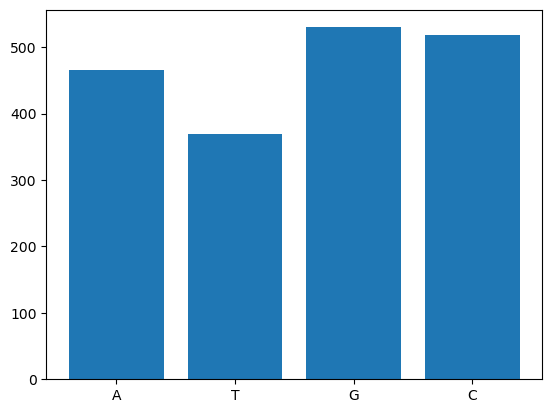

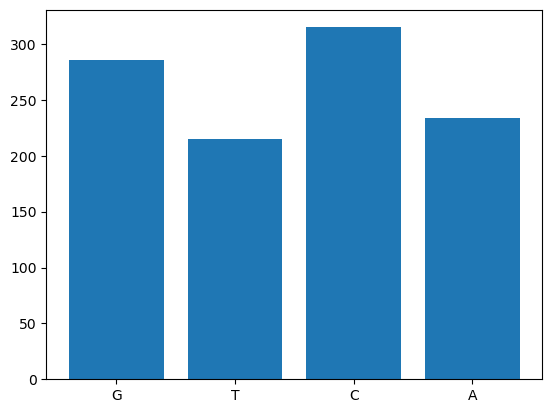

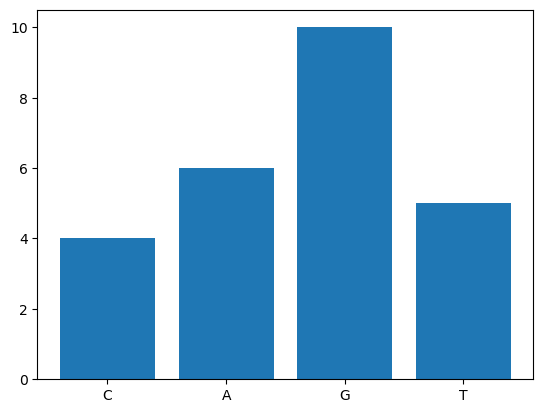

In [129]:
print('2a.')

counterA = Counter(seqA)
counterB = Counter(seqB)
counterC = Counter(seqC)

plt.bar(counterA.keys(), counterA.values())
plt.show()
plt.bar(counterB.keys(), counterB.values())
plt.show()
plt.bar(counterC.keys(), counterC.values())
plt.show()

In [130]:
def counter(sequence, target_1, target_2):
  count_1 = sequence.count(target_1)
  count_2 = sequence.count(target_2)
  return count_1 + count_2

def seq_counter(sequence, target):
  target_count = counter(sequence, target[0], target[1])
  return target_count

def percentage(sequence):
  GC_percentage = seq_counter(sequence, 'GC') / len(sequence) * 100
  AT_percentage = seq_counter(sequence, 'AT') / len(sequence) * 100
  return (GC_percentage, AT_percentage)

In [131]:
print('2b.')
print(f'Sequence A: {percentage(seqA)[0]:.2f}% {percentage(seqA)[1]:.2f}%')
print(f'Sequence B: {percentage(seqB)[0]:.2f}% {percentage(seqB)[1]:.2f}%')
print(f'Sequence C: {percentage(seqC)[0]:.2f}% {percentage(seqC)[1]:.2f}%')

2b.
Sequence A: 55.71% 44.29%
Sequence B: 57.24% 42.76%
Sequence C: 56.00% 44.00%


In [132]:
from Bio.SeqUtils import MeltingTemp as mt

print('2c.')
melt_A = mt.Tm_Wallace(seqA)
melt_B = mt.Tm_Wallace(seqB)
melt_C = mt.Tm_Wallace(seqC)

print(f'Melting point of sequence A: {melt_A}')
print(f'Melting point of sequence B: {melt_B}')
print(f'Melting point of sequence C: {melt_C}')

2c.
Melting point of sequence A: 5864.0
Melting point of sequence B: 3302.0
Melting point of sequence C: 78.0


In [133]:
from Bio.SeqUtils import molecular_weight as mw
print('2d.')
print(f'Molecular weight of sequence A: {mw(seqA)}')
print(f'Molecular weight of sequence B: {mw(seqB)}')
print(f'Molecular weight of sequence C: {mw(seqC)}')

2d.
Molecular weight of sequence A: 582470.8097999999
Molecular weight of sequence B: 323955.0287
Molecular weight of sequence C: 7867.0065


# 3. DNA & mRNA Protein Synthesis

In [134]:
seqA_t = seqA.transcribe()
seqB_t = seqB.transcribe()
seqC_t = seqC.transcribe()

print('mRNA result of Sequence A:', seqA_t)
print('mRNA result of Sequence B:', seqB_t)
print('mRNA result of Sequence C:', seqC_t)

mRNA result of Sequence A: AUGGUGUUGGAUCUGGACUUGUUUCGGACGGAUAAAGGAGGAGACCCGGACCGCAUCCGAGAGACGCAAAAGAACCGCUUCAAGGACCCGGGACUCGUGGAUCGGCUGGUGAAGGCGGACGGCGAGUGGCGAAAAUGCAGAUUUCAGACCGACAACUUGAACAAGCUGAAGAACCUAUGCAGCAAGACAAUUGGAGAGAAAAUGAAGAAAAAAGAGCCAGUGGGAAAUGAUGAGUCCAUUCCGGAGAACUUGUUAAAUCUCGAUGACCUCACUUCAGACACUUUAGCUAACCUGAAAGUGUCACAGAUCAAAAAACUCCGACUCCUCAUCGACGAAGCCAUCCUGAAGUGUGACGCCCAGCGGAUAAAGCUGCAGGAAUAGCGGUUUGAGAACCUCCGCGAGCGAUUCGAUGGCUAGGUCCUGCAUCCCUCGGUGCCCAUCAGUAACGAUGAGGAUGCGGACAACAAAGUCGAGAGGAUCUGGGGUGACUGCACCGUCAAGAAGAAGUACUCGCACGUGGACCUGGUGGUGAUGGUCGAUGGCUUUGAAGGCGAAAAAGGGGUCGUGGUGGCUGGCAGUCGAGGGUACUUCCUGAAGGGGCCCCUGGUGUUCCUGGAACAGGCGCUCAUCCAGUACGCCCUUCGCACCUUGGGAAGUCGGGGCUACAUUCCCAUUUACACCCCGUUUUUCAUGAGGAAGGAGGUCAUGCAGGAGGUGGCACAGCUCAGCCAGUUUGAUGAAGAGCUUUACAAGGUGAUUGGCAAAGGCAGUGAAAAGUCUGACGACAACUCCUACGAUGAGAAAUACCUGAUUGCCACCUCCGAGCAGCCCAUCGCUGCUCUCCACCGAGAUGAGUGGCUACGGCCAGAGGAUUUGCCCAUCAAGUAUGCUGGCCUGUCCACCUGCUUUCGCCAGGAGGUGGGCUCCCACGGCCGGGACACCCGCGGCAUCUUCCGAGUCCAUCAGUUUGAGA

In [135]:
print('mRNA result of Sequence A:', seqA_t.translate())
print('mRNA result of Sequence B:', seqB_t.translate())
print('mRNA result of Sequence C:', seqC_t.translate())

mRNA result of Sequence A: MVLDLDLFRTDKGGDPDRIRETQKNRFKDPGLVDRLVKADGEWRKCRFQTDNLNKLKNLCSKTIGEKMKKKEPVGNDESIPENLLNLDDLTSDTLANLKVSQIKKLRLLIDEAILKCDAQRIKLQE*RFENLRERFDG*VLHPSVPISNDEDADNKVERIWGDCTVKKKYSHVDLVVMVDGFEGEKGVVVAGSRGYFLKGPLVFLEQALIQYALRTLGSRGYIPIYTPFFMRKEVMQEVAQLSQFDEELYKVIGKGSEKSDDNSYDEKYLIATSEQPIAALHRDEWLRPEDLPIKYAGLSTCFRQEVGSHGRDTRGIFRVHQFEKIEQFVYASPHDNKSWEMFEEMISTAEEFYQTLGIPYHIVNIVSGSLNHAASKKLDLEAWFPGSGAFRELVSCSNCTDYQARRLRIRYGQTKKMMDKVEFVHMLNATMCATTRTICAILENYQTEKGIVVPEKLKEFMPPGLQELIPFVKPAPIDQEPSKKQKKQQEGSKNKGAESDVPLESRLQSMVLADS*TFLLPSSVSWDPRACPQAGTPDMPSHRLHRLTALLKREPSAMHTAVFLSARMGLGRNH*GLRKSCHEPPQQR*GLARSPPPGPQTLAHSSPWNHTHLCFSS*IKLFHVAS
mRNA result of Sequence B: VSVELWQQCVELLRDELPAQQFNTWIRPLQVEAEGDELRVYAPNRFVLDWVNEKYLSRVLELLDEHGNGLAPVLSLLIGSKRSSAPRAAPNAPLAAAASQAQAAPVASTPAPAPSKSSAKKNAAENEEPSRDSFDPMAGASSQQAPIRAEQRTVQVEGALKHTSYLNRTFTFENFVEGKSNQLARAAAWQVADNPKHGYNPLFLYGGVGLGKTHLMHAVGNHLLKKNPNAKVVYLHSERFVADMVKALQLNAINEFKRFYRSVDALLIDDIQFFARKERSQEEFFHTFNALLEGGQQVILTSDRYPKEIEGLEERLKS

c:\Users\Britod\.conda\envs\computational_biology\Lib\site-packages\Bio\Seq.py:2879: BiopythonWarning: Partial codon, len(sequence) not a multiple of three. Explicitly trim the sequence or add trailing N before translation. This may become an error in future.
  warnings.warn(


# 4. Sequence Alignment & Similarities

In [136]:
from Bio import pairwise2 as pw
from Bio.pairwise2 import format_alignment as fa
from Levenshtein import distance

In [137]:
localxx = pw.align.localxx(seqA, 'CGCTACTAGCATGCGCAT')
print(fa(*localxx[0]))

1815 CAGCTCTCCCTGGAACCACACTCACTTGTGCTTTTCCTCCTAAATAAAGCTGTTCCATGTAGCAAGT
     | |      ||        ||| |     |         |       |  ||   |     || | |
   1 C-G------CT--------ACT-A-----G---------C-------A--TG---C-----GC-A-T
  Score=18



In [138]:
globalxx = pw.align.globalxx(seqA, 'CAGTGCGCTAGCAGCTACGTGTG')
print(fa(*globalxx[0]))

ATGGTGTTGGATCTGGACTTGTTTCGGACGGATAAAGGAGGAGACCCGGACCGCATCCGAGAGACGCAAAAGAACCGCTTCAAGGACCCGGGACTCGTGGATCGGCTGGTGAAGGCGGACGGCGAGTGGCGAAAATGCAGATTTCAGACCGACAACTTGAACAAGCTGAAGAACCTATGCAGCAAGACAATTGGAGAGAAAATGAAGAAAAAAGAGCCAGTGGGAAATGATGAGTCCATTCCGGAGAACTTGTTAAATCTCGATGACCTCACTTCAGACACTTTAGCTAACCTGAAAGTGTCACAGATCAAAAAACTCCGACTCCTCATCGACGAAGCCATCCTGAAGTGTGACGCCCAGCGGATAAAGCTGCAGGAATAGCGGTTTGAGAACCTCCGCGAGCGATTCGATGGCTAGGTCCTGCATCCCTCGGTGCCCATCAGTAACGATGAGGATGCGGACAACAAAGTCGAGAGGATCTGGGGTGACTGCACCGTCAAGAAGAAGTACTCGCACGTGGACCTGGTGGTGATGGTCGATGGCTTTGAAGGCGAAAAAGGGGTCGTGGTGGCTGGCAGTCGAGGGTACTTCCTGAAGGGGCCCCTGGTGTTCCTGGAACAGGCGCTCATCCAGTACGCCCTTCGCACCTTGGGAAGTCGGGGCTACATTCCCATTTACACCCCGTTTTTCATGAGGAAGGAGGTCATGCAGGAGGTGGCACAGCTCAGCCAGTTTGATGAAGAGCTTTACAAGGTGATTGGCAAAGGCAGTGAAAAGTCTGACGACAACTCCTACGATGAGAAATACCTGATTGCCACCTCCGAGCAGCCCATCGCTGCTCTCCACCGAGATGAGTGGCTACGGCCAGAGGATTTGCCCATCAAGTATGCTGGCCTGTCCACCTGCTTTCGCCAGGAGGTGGGCTCCCACGGCCGGGACACCCGCGGCATCTTCCGAGTCCATCAGTTTGAGAAGATCGAGCAGTTTGTCTACGCGTCAC

In [139]:
levenshtein = distance(seqA, seqB)
print(levenshtein)

1039
